# DoanTanMinhTan - RNN Homework

Time Series Prediction with RNN

In [29]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [30]:
# Generate synthetic data
N = 500
t = np.arange(N)

f1 = np.sin(0.1 * t)
f2 = np.cos(0.1 * t)
f3 = t * 0.01
target = np.sin(0.1 * (t + 1))

data = np.stack([f1, f2, f3, target], axis=1)

X = data[:, :3]
y = data[:, 3:]

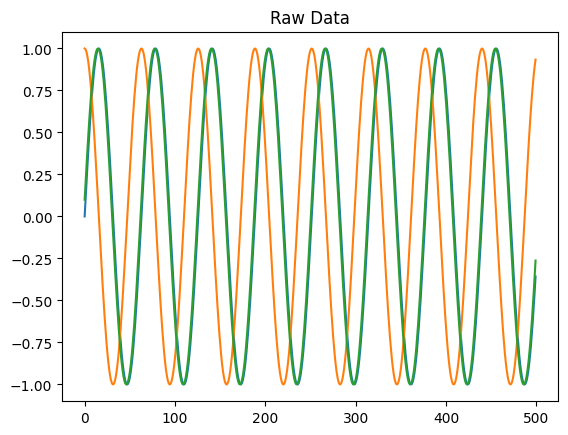

In [31]:
plt.figure()
plt.plot(f1)
plt.plot(f2)
plt.plot(target)
plt.title("Raw Data")
plt.show()

In [32]:
def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

seq_length = 50
X_seq, y_seq = create_sequences(X, y, seq_length)

In [33]:
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

In [34]:
class RNNModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=8):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = RNNModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

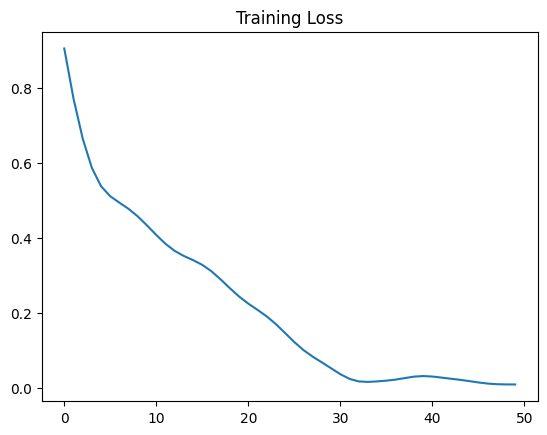

In [35]:
losses = []

for epoch in range(50):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

plt.figure()
plt.plot(losses)
plt.title("Training Loss")
plt.show()

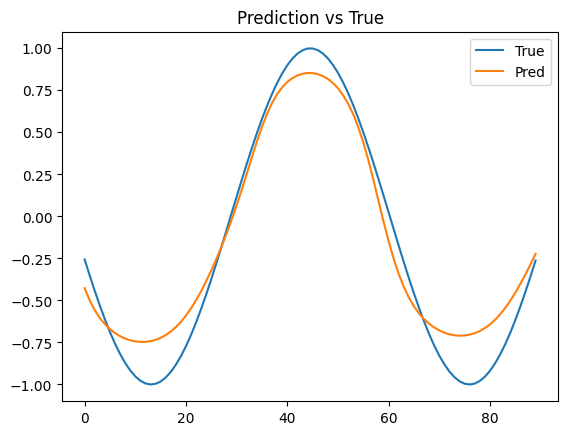

In [36]:
model.eval()
with torch.no_grad():
    preds = model(X_test)

plt.figure()
plt.plot(y_test.numpy(), label="True")
plt.plot(preds.numpy(), label="Pred")
plt.legend()
plt.title("Prediction vs True")
plt.show()